# mDeBERTa-v3 Subjectivity Classification Evaluation

Evaluate `GroNLP/mdebertav3-subjectivity-english` on distinguishing **objective** from **subjective** sentences in academic peer-review sections.

**Pipeline:**
1. Use sentences from `/data/test_dataset.csv`
2. Run each through the HuggingFace classifier locally (no Ollama, no API key)
3. Collect structured output: `label`, `confidence`
4. Analyse model performance

---
### Setup
```bash
pip install transformers torch pandas matplotlib
```

In [45]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, HTML
from transformers import pipeline

MODEL_NAME = "GroNLP/mdebertav3-subjectivity-english"
CSV_PATH = Path("./data/test_dataset.csv")
BATCH_SIZE = 16
OUTPUT_CSV = "./results/mdebertav3_results.csv"
# label_0 = OBJECTIVE, label_1 = SUBJECTIVE (per GroNLP model card)
LABEL_MAP = {"label_0": "objective", "label_1": "subjective"}

## 1. Load Model

In [24]:
classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=-1,
    truncation=True,
    max_length=512,
)
print("Model loaded successfully.")

Device set to use cpu


Model loaded successfully.


## 2. Import Data

In [25]:
df_sample = pd.read_csv(CSV_PATH)
df_sample.index += 1
print(f"Loaded {len(df_sample)} sentences for evaluation")
df_sample[["paper_title", "reviewer", "sentence", "matched_markers"]].head(5)

Loaded 100 sentences for evaluation


,paper_title,reviewer,sentence,matched_markers
1,Reframing attention as a reinforcement learnin...,ICLR.cc/2026/Conference/Submission25201/Review...,"Some key symbols (e.g., $J^t$) are used before...",NaN
2,THE JPEG BLIND SPOT: EXPOSING A CRITICAL VULNE...,ICLR.cc/2026/Conference/Submission25466/Review...,Prior literature has extensively documented th...,NaN
3,DIANA with Compression for Distributed Variati...,ICLR.cc/2026/Conference/Submission25336/Review...,Error feedback is typically useful for biased ...,NaN
4,Curricular Adversarial Training for Robust Cod...,ICLR.cc/2026/Conference/Submission25575/Review...,Only high-level summaries are given—no impleme...,NaN
5,On the (In)Significance of Feature Selection i...,ICLR.cc/2026/Conference/Submission25529/Review...,The dataset selection process is not described.,NaN


## 3. Run Inference

Unlike the Qwen approach (generative + JSON parsing), mDeBERTa is a
**fine-tuned sequence classifier**. We feed sentences in batches and receive
`label` + `score` directly — no prompt engineering or parsing required.

In [36]:
sentences = df_sample["sentence"].tolist()

raw_preds = classifier(sentences, batch_size=BATCH_SIZE)

results = []
for i, (row_idx, row) in enumerate(df_sample.iterrows()):
    pred = raw_preds[i]
    label = LABEL_MAP.get(pred["label"], pred["label"].lower())
    conf = round(pred["score"], 4)

    results.append({
        "idx": row_idx,
        "paper_title": row["paper_title"],
        "reviewer": row["reviewer"],
        "sentence": row["sentence"],
        "matched_markers": row["matched_markers"],
        "ground_truth": str(row["label"]).lower().strip(),
        "label": label,
        "confidence": conf,
    })

print(f"Done. {len(results)} predictions collected.")

Done. 100 predictions collected.


## 4. Results DataFrame

In [37]:
df_results = pd.DataFrame(results)
df_results["label"] = df_results["label"].map(LABEL_MAP).fillna(df_results["label"])
df_results["correct"] = df_results["label"] == df_results["ground_truth"]

display_cols = ["idx", "label", "ground_truth", "confidence", "correct", "matched_markers", "sentence"]
df_results[display_cols].head(10)

,idx,label,ground_truth,confidence,correct,matched_markers,sentence
0,1,objective,objective,0.8104,True,NaN,"Some key symbols (e.g., $J^t$) are used before..."
1,2,objective,objective,0.7702,True,NaN,Prior literature has extensively documented th...
2,3,objective,objective,0.7314,True,NaN,Error feedback is typically useful for biased ...
3,4,objective,objective,0.7548,True,NaN,Only high-level summaries are given—no impleme...
4,5,objective,objective,0.8930,True,NaN,The dataset selection process is not described.
5,6,objective,objective,0.6028,True,NaN,No justification is provided for defining exac...
6,7,objective,objective,0.8777,True,NaN,"There's no ablation for particle‑per‑cell, int..."
7,8,objective,objective,0.8786,True,NaN,The approach assumes access to reasonably accu...
8,9,subjective,objective,0.8287,False,NaN,"What is a corridor constant, and what does it ..."
9,10,objective,objective,0.7933,True,NaN,"Consequently, the paper’s findings highlight v..."


## 5. Detailed Output – Label / Confidence

In [38]:
for _, row in df_results.iterrows():
    label = row["label"]
    gt = row["ground_truth"]
    conf = row["confidence"]
    sentence = row["sentence"]
    markers = row["matched_markers"]
    correct = row["correct"]

    tick = "✓" if correct else "✗"
    label_color = "#2ecc71" if label == "subjective" else "#e74c3c"
    border = "#2ecc71" if correct else "#e74c3c"
    conf_str = f"{conf:.0%}"

    html = f"""
    <div style="border-left:4px solid {border}; padding:8px 12px; margin:10px 0;
                font-family:monospace; font-size:13px; background:#fafafa;">
      <b>#{row['idx']}</b>&nbsp;
      <span style="background:{label_color}; color:#fff; border-radius:3px;
                   padding:1px 6px; margin-right:6px;">{label.upper()}</span>
      <span style="color:#555;">Confidence: <b>{conf_str}</b></span>
      <span style="color:#999; margin-left:10px;">Ground truth: {gt.upper()}</span>
      <span style="float:right; font-size:16px;">{tick}</span><br/>
      <div style="margin:6px 0; color:#333;">"{sentence}"</div>
      <div style="color:#888; font-size:11px;">Markers: {markers}</div>
    </div>
    """
    display(HTML(html))

## 6. Performance Summary

In [39]:
n_total = len(df_results)
n_correct = df_results["correct"].sum()
accuracy = n_correct / n_total

label_counts = df_results["label"].value_counts()
gt_counts = df_results["ground_truth"].value_counts()
avg_conf_subj = df_results.loc[df_results["label"] == "subjective", "confidence"].mean()
avg_conf_obj = df_results.loc[df_results["label"] == "objective",  "confidence"].mean()

print(f"Model: {MODEL_NAME}")
print(f"Total samples: {n_total}")
print(f"Correct: {n_correct}/{n_total}  →  {accuracy:.1%}")
print()
print("Ground-truth distribution:")
print(gt_counts.to_string())
print()
print("Model label distribution:")
print(label_counts.to_string())
print()
print(f"Avg confidence when labelled SUBJECTIVE: {avg_conf_subj:.2f}")
print(f"Avg confidence when labelled OBJECTIVE: {avg_conf_obj:.2f}")

Model: GroNLP/mdebertav3-subjectivity-english
Total samples: 100
Correct: 77/100  →  77.0%

Ground-truth distribution:
ground_truth
objective     50
subjective    50

Model label distribution:
label
objective     67
subjective    33

Avg confidence when labelled SUBJECTIVE: 0.65
Avg confidence when labelled OBJECTIVE: 0.76


## 7. Confusion Matrix & Classification Report

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = df_results["ground_truth"]
y_pred = df_results["label"]

print(classification_report(y_true, y_pred, target_names=["objective", "subjective"]))

cm = confusion_matrix(y_true, y_pred, labels=["objective", "subjective"])
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index =["True OBJ", "True SUBJ"], columns =["Pred OBJ", "Pred SUBJ"]))

              precision    recall  f1-score   support

   objective       0.70      0.94      0.80        50
  subjective       0.91      0.60      0.72        50

    accuracy                           0.77       100
   macro avg       0.81      0.77      0.76       100
weighted avg       0.81      0.77      0.76       100

Confusion matrix (rows=true, cols=pred):
           Pred OBJ  Pred SUBJ
True OBJ         47          3
True SUBJ        20         30


## 8. Visualisations

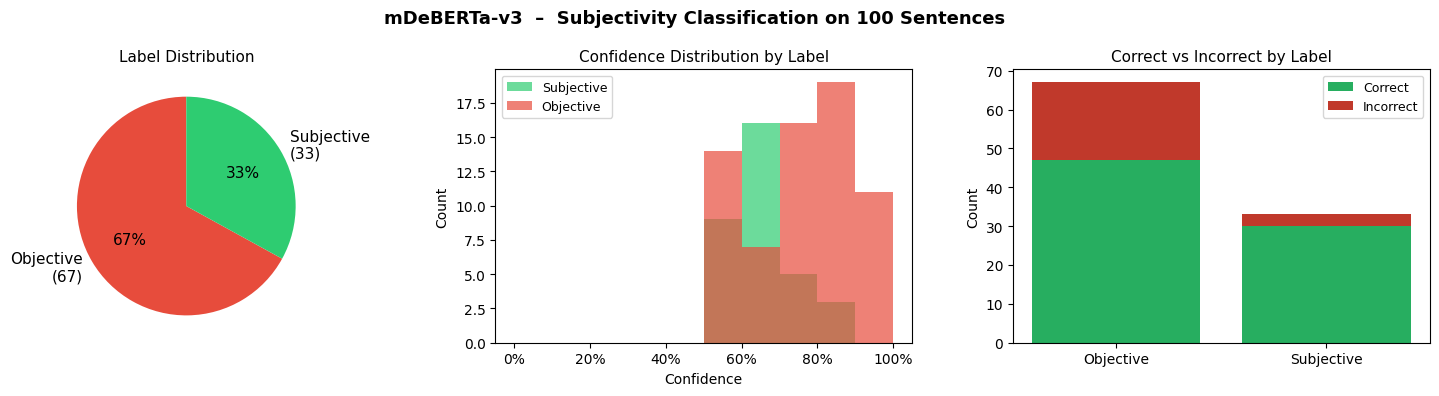

Saved: mdeberta_eval_results.png


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"mDeBERTa-v3  –  Subjectivity Classification on {n_total} Sentences",
             fontsize=13, fontweight="bold")

ax = axes[0]
counts = df_results["label"].value_counts()
colors = {"subjective": "#2ecc71", "objective": "#e74c3c"}
ax.pie(
    counts.values,
    labels=[f"{l.capitalize()}\n({v})" for l, v in counts.items()],
    colors=[colors.get(l, "#bdc3c7") for l in counts.index],
    autopct="%1.0f%%", startangle=90,
    textprops={"fontsize": 11},
)
ax.set_title("Label Distribution", fontsize=11)

ax = axes[1]
for lbl, color in [("subjective", "#2ecc71"), ("objective", "#e74c3c")]:
    subset = df_results.loc[df_results["label"] == lbl, "confidence"].dropna()
    if len(subset):
        ax.hist(subset, bins=10, alpha=0.7, color=color, label=lbl.capitalize(),
                range=(0, 1))
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution by Label", fontsize=11)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax = axes[2]
correct_by_label = df_results.groupby("label")["correct"].agg(["sum", "count"])
correct_by_label["wrong"] = correct_by_label["count"] - correct_by_label["sum"]
x = range(len(correct_by_label))
ax.bar(x, correct_by_label["sum"],   label="Correct",   color="#27ae60")
ax.bar(x, correct_by_label["wrong"], label="Incorrect", color="#c0392b",
       bottom=correct_by_label["sum"])
ax.set_xticks(list(x))
ax.set_xticklabels(correct_by_label.index.str.capitalize(), fontsize=10)
ax.set_ylabel("Count")
ax.set_title("Correct vs Incorrect by Label", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("mdeberta_eval_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mdeberta_eval_results.png")

## 9. Misclassified Sentences

In [42]:
misclassified = df_results[~df_results["correct"]].copy()
print(f"Misclassified: {len(misclassified)} / {n_total}")

if len(misclassified) > 0:
    for _, row in misclassified.iterrows():
        print(f"\n[#{row['idx']}] Predicted: {row['label'].upper()}  "
              f"| Ground truth: {row['ground_truth'].upper()}  "
              f"| Confidence: {row['confidence']:.0%}")
        print(f"  Sentence: {row['sentence'][:200]}")
        print(f"  Markers: {row['matched_markers']}")
else:
    print("Perfect accuracy — no misclassifications!")

Misclassified: 23 / 100

[#9] Predicted: SUBJECTIVE  | Ground truth: OBJECTIVE  | Confidence: 83%
  Sentence: What is a corridor constant, and what does it mean to be explicit and falsifiable?
  Markers: nan

[#15] Predicted: SUBJECTIVE  | Ground truth: OBJECTIVE  | Confidence: 56%
  Sentence: Lack of introducing the insight-based memory work, like Expel[1], MSI-Agent[2] and SelfGoal[3].
  Markers: nan

[#39] Predicted: SUBJECTIVE  | Ground truth: OBJECTIVE  | Confidence: 51%
  Sentence: Since the kernel implicitly defines a density estimator, the fairness performance could be highly sensitive to kernel type and bandwidth.
  Markers: nan

[#54] Predicted: OBJECTIVE  | Ground truth: SUBJECTIVE  | Confidence: 54%
  Sentence: The authors should, for instance, discuss how their framework compares to general-purpose multi-agent frameworks like AutoGen or CrewAI, and why a bespoke system was necessary. - Insufficient comparis
  Markers: Insufficient

[#57] Predicted: OBJECTIVE  | Ground trut

## 10. Save Full Results to CSV

In [46]:
out_cols = [
    "idx", "paper_title", "reviewer",
    "sentence", "matched_markers",
    "ground_truth", "label", "confidence", "correct",
]

df_out = df_results[[c for c in out_cols if c in df_results.columns]]
df_out.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df_out)} rows → {OUTPUT_CSV}")
df_out.head()

Saved 100 rows → ./results/mdebertav3_results.csv


,idx,paper_title,reviewer,sentence,matched_markers,ground_truth,label,confidence,correct
0,1,Reframing attention as a reinforcement learnin...,ICLR.cc/2026/Conference/Submission25201/Review...,"Some key symbols (e.g., $J^t$) are used before...",NaN,objective,objective,0.8104,True
1,2,THE JPEG BLIND SPOT: EXPOSING A CRITICAL VULNE...,ICLR.cc/2026/Conference/Submission25466/Review...,Prior literature has extensively documented th...,NaN,objective,objective,0.7702,True
2,3,DIANA with Compression for Distributed Variati...,ICLR.cc/2026/Conference/Submission25336/Review...,Error feedback is typically useful for biased ...,NaN,objective,objective,0.7314,True
3,4,Curricular Adversarial Training for Robust Cod...,ICLR.cc/2026/Conference/Submission25575/Review...,Only high-level summaries are given—no impleme...,NaN,objective,objective,0.7548,True
4,5,On the (In)Significance of Feature Selection i...,ICLR.cc/2026/Conference/Submission25529/Review...,The dataset selection process is not described.,NaN,objective,objective,0.8930,True
